

# Project : GraphRAG for Multi-Hop Questions

Normal RAG finds similar text. GraphRAG builds a knowledge graph from the text and walks it, which helps for questions that need several connected facts (multi-hop).

## What this notebook does
- Uses 14 short passages about a made-up group of companies and people
- Uses Groq to extract knowledge graph triples (subject, relation, object) from each passage, with a backup list if extraction fails
- Builds a NetworkX graph and draws it
- Answers 10 questions (1, 2 and 3 hops) with 4 methods: vector top 3, all passages in the prompt, fixed 3-hop graph, and adaptive-hop graph
- Checks the extracted triples against a hand-written list, then scores the methods on accuracy, context size and hops
- Finds communities in the graph and writes community summaries for global questions

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again
4. This notebook makes about 85 API calls.

## Step 1: Install libraries

In [1]:
!pip install -q networkx sentence-transformers openai pandas numpy matplotlib

## Step 2: Connect to Groq (the AI part)
Paste your Groq API key when it asks. The key is hidden while you type.

In [2]:
import time
from getpass import getpass
from openai import OpenAI

GROQ_KEY = getpass("Paste your Groq API key: ")
client = OpenAI(api_key=GROQ_KEY, base_url="https://api.groq.com/openai/v1")
MODEL = "openai/gpt-oss-120b"

def ask_llm(question, system="You are a helpful analyst.", model=MODEL):
    for tries in range(3):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system}, {"role": "user", "content": question}],
                max_tokens=1500,
                temperature=0.3,
            )
            return r.choices[0].message.content
        except Exception as e:
            print("llm error, trying again:", str(e)[:100])
            time.sleep(5)
    return "LLM not available right now."

print(ask_llm("Say hi in five words."))

Paste your Groq API key: ··········
Hey there, great to see!


## Step 3: The passages and questions
All names are made up so the model cannot answer from its own memory.

In [3]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"
import re, json, time, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

passages = [
    "Riya Sharma founded Nimbus Labs in Bhopal in 2016.",
    "Nimbus Labs builds warehouse robots for retailers.",
    "Orion Systems acquired Nimbus Labs in 2021.",
    "Orion Systems is headquartered in Pune and is led by CEO Vikram Rao.",
    "Vikram Rao studied at IIT Indore before joining Orion Systems.",
    "Riya Sharma later joined the board of GreenGrid, a solar energy company.",
    "GreenGrid supplies solar panels to Helix Motors.",
    "Helix Motors is an electric vehicle maker based in Chennai, and its CEO is Arjun Mehta.",
    "Arjun Mehta previously worked at Orion Systems as head of strategy.",
    "Helix Motors partnered with Nimbus Labs to automate its battery plant.",
    "GreenGrid was founded by Sunita Patel and is headquartered in Jaipur.",
    "Sunita Patel is an alumna of IIT Indore.",
    "Zephyr Analytics is a data company in Hyderabad led by CEO Meena Iyer.",
    "Orion Systems also has an office in Bengaluru.",
]

questions = [
    {"q": "What does Nimbus Labs build?", "gold": "warehouse robots", "hops": 1},
    {"q": "Who founded GreenGrid?", "gold": "Sunita Patel", "hops": 1},
    {"q": "Which city is Helix Motors based in?", "gold": "Chennai", "hops": 1},
    {"q": "Who is the CEO of the company that acquired Nimbus Labs?", "gold": "Vikram Rao", "hops": 2},
    {"q": "Who is the CEO of the company that GreenGrid supplies solar panels to?", "gold": "Arjun Mehta", "hops": 2},
    {"q": "In which city is the company whose board Riya Sharma joined headquartered?", "gold": "Jaipur", "hops": 2},
    {"q": "In which city is the company that acquired the startup founded by Riya Sharma headquartered?", "gold": "Pune", "hops": 3},
    {"q": "Which college did the CEO of the company that acquired Nimbus Labs attend?", "gold": "IIT Indore", "hops": 3},
    {"q": "Where is the company that the CEO of Helix Motors previously worked for headquartered?", "gold": "Pune", "hops": 3},
    {"q": "Which college did the founder of the company that supplies solar panels to Helix Motors attend?", "gold": "IIT Indore", "hops": 3},
]
print(len(passages), "passages,", len(questions), "questions")

14 passages, 10 questions


## Step 4: Extract triples with Groq
Each passage becomes a few (subject, relation, object) facts.

In [4]:
def parse_triples(text):
    m = re.search(r"\[\s*\[.*\]\s*\]", text, re.DOTALL)
    if not m:
        return []
    try:
        items = json.loads(m.group(0))
    except Exception:
        return []
    out = []
    for it in items:
        if isinstance(it, list) and len(it) == 3:
            out.append((str(it[0]).strip(), str(it[1]).strip().lower().replace(" ", "_"), str(it[2]).strip()))
    return out

extract_prompt = """Extract knowledge graph triples from the text.
Return ONLY a JSON list of [subject, relation, object] lists. Use full entity names (like 'Orion Systems'), short lowercase relations
(like founded, acquired, ceo, headquartered_in, studied_at, based_in, supplies, board_member_of, builds, partnered_with, works_at, previously_worked_at, founded_by),
use works_at when someone joined or is employed by a company, and previously_worked_at only when the text says they used to work there,
and put the company or person as subject or object, not a sentence.
Text: """

all_triples = []
for i, p in enumerate(passages):
    reply = ask_llm(extract_prompt + p, system="You extract triples and return only JSON.")
    triples = parse_triples(reply)
    for t in triples:
        all_triples.append({"subject": t[0], "relation": t[1], "object": t[2], "passage": i})
    time.sleep(0.3)

print("Triples from Groq:", len(all_triples))

backup = [
    ("Riya Sharma", "founded", "Nimbus Labs"), ("Nimbus Labs", "builds", "warehouse robots"), ("Orion Systems", "acquired", "Nimbus Labs"),
    ("Orion Systems", "headquartered_in", "Pune"), ("Orion Systems", "ceo", "Vikram Rao"), ("Vikram Rao", "studied_at", "IIT Indore"),
    ("Riya Sharma", "board_member_of", "GreenGrid"), ("GreenGrid", "supplies", "Helix Motors"), ("Helix Motors", "based_in", "Chennai"),
    ("Helix Motors", "ceo", "Arjun Mehta"), ("Arjun Mehta", "previously_worked_at", "Orion Systems"), ("Helix Motors", "partnered_with", "Nimbus Labs"),
    ("GreenGrid", "founded_by", "Sunita Patel"), ("GreenGrid", "headquartered_in", "Jaipur"), ("Sunita Patel", "studied_at", "IIT Indore"),
    ("Zephyr Analytics", "headquartered_in", "Hyderabad"), ("Zephyr Analytics", "ceo", "Meena Iyer"), ("Orion Systems", "has_office_in", "Bengaluru"), ("Nimbus Labs", "based_in", "Bhopal"), ("Vikram Rao", "works_at", "Orion Systems"),
]
triples_df = pd.DataFrame(all_triples, columns=["subject", "relation", "object", "passage"]).drop_duplicates(subset=["subject", "relation", "object"]).reset_index(drop=True)
if len(triples_df) < 12:
    print("Extraction gave too few unique triples, using the backup list instead")
    triples_df = pd.DataFrame([{"subject": a, "relation": r, "object": b, "passage": -1} for a, r, b in backup])
print("Unique triples:", len(triples_df))
triples_df.head(15)

Triples from Groq: 20
Unique triples: 20


,subject,relation,object,passage
0,Riya Sharma,founded,Nimbus Labs,0
1,Nimbus Labs,based_in,Bhopal,0
2,Nimbus Labs,builds,warehouse robots,1
3,Orion Systems,acquired,Nimbus Labs,2
4,Orion Systems,headquartered_in,Pune,3
5,Orion Systems,ceo,Vikram Rao,3
6,Vikram Rao,studied_at,IIT Indore,4
7,Vikram Rao,works_at,Orion Systems,4
8,Riya Sharma,board_member_of,GreenGrid,5
9,GreenGrid,supplies,Helix Motors,6


## Step 5: Build the graph
Small name variants (like `Orion` and `Orion Systems`) are merged into the longer name.

Nodes: 18  Edges: 20


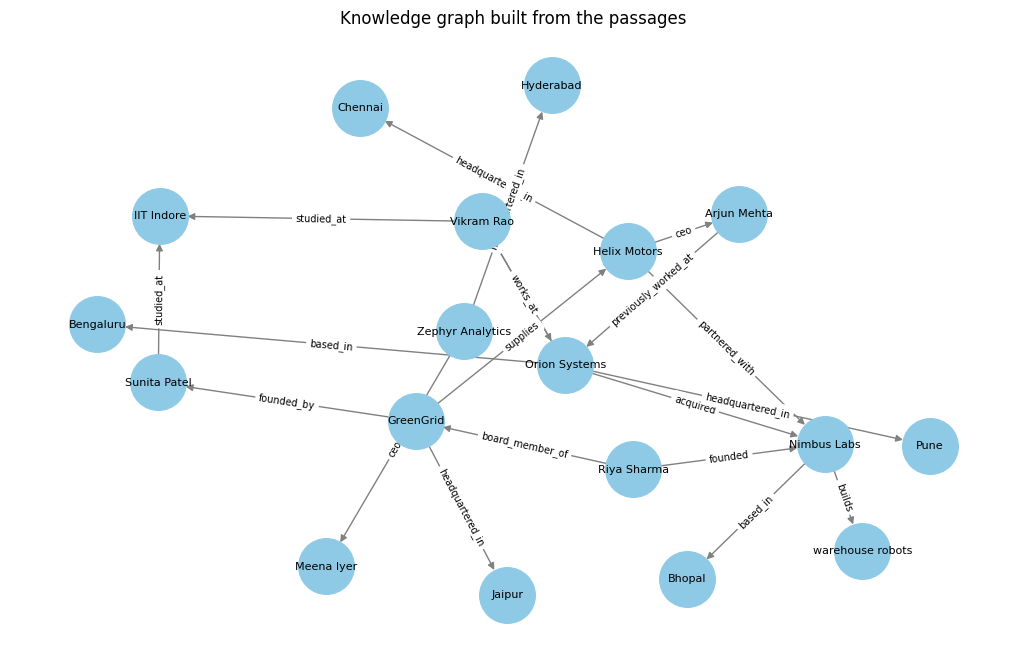

In [5]:
names = set(triples_df["subject"]).union(set(triples_df["object"]))

def canon(name):
    best = name
    for other in names:
        if other != name and len(other) > len(best) and re.search(r"\b" + re.escape(name.lower()) + r"\b", other.lower()):
            best = other
    return best

triples_df["subject"] = triples_df["subject"].apply(canon)
triples_df["object"] = triples_df["object"].apply(canon)
triples_df = triples_df.drop_duplicates(subset=["subject", "relation", "object"]).reset_index(drop=True)

G = nx.DiGraph()
for i in range(len(triples_df)):
    G.add_edge(triples_df.loc[i, "subject"], triples_df.loc[i, "object"], relation=triples_df.loc[i, "relation"])
print("Nodes:", G.number_of_nodes(), " Edges:", G.number_of_edges())

plt.figure(figsize=(13, 8))
pos = nx.spring_layout(G, seed=4, k=0.9)
nx.draw_networkx_nodes(G, pos, node_color="#8ecae6", node_size=1600)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, arrows=True, edge_color="gray", node_size=1600)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "relation"), font_size=7)
plt.title("Knowledge graph built from the passages")
plt.axis("off")
plt.show()

## Step 5b: Check the extracted triples
The backup list was written by hand from the passages. We compare the AI-extracted triples with it. Bad triples would quietly hurt every answer below.

In [6]:
gold_pairs = set((a.lower(), b.lower()) for a, r, b in backup)
got_pairs = set((a.lower(), b.lower()) for a, b in zip(triples_df["subject"], triples_df["object"]))

def pair_in(p, pool):
    return p in pool or (p[1], p[0]) in pool

recall = sum(pair_in(p, got_pairs) for p in gold_pairs) / len(gold_pairs)
precision = sum(pair_in(p, gold_pairs) for p in got_pairs) / len(got_pairs)
print("Extraction recall (hand-written facts found):", round(recall * 100, 1), "%")
print("Extraction precision (extracted facts that are in the hand-written list):", round(precision * 100, 1), "%")

missing = [p for p in gold_pairs if not pair_in(p, got_pairs)]
extra = [p for p in got_pairs if not pair_in(p, gold_pairs)]
print("\nHand-written facts the AI missed:", missing)
print("Extra facts the AI added (read these, they may be fine or wrong):", extra)

print("\nRelations to read by hand:")
print(triples_df[["subject", "relation", "object"]].to_string(index=False))

Extraction recall (hand-written facts found): 100.0 %
Extraction precision (extracted facts that are in the hand-written list): 100.0 %

Hand-written facts the AI missed: []
Extra facts the AI added (read these, they may be fine or wrong): []

Relations to read by hand:
         subject             relation           object
     Riya Sharma              founded      Nimbus Labs
     Nimbus Labs             based_in           Bhopal
     Nimbus Labs               builds warehouse robots
   Orion Systems             acquired      Nimbus Labs
   Orion Systems     headquartered_in             Pune
   Orion Systems                  ceo       Vikram Rao
      Vikram Rao           studied_at       IIT Indore
      Vikram Rao             works_at    Orion Systems
     Riya Sharma      board_member_of        GreenGrid
       GreenGrid             supplies     Helix Motors
    Helix Motors     headquartered_in          Chennai
    Helix Motors                  ceo      Arjun Mehta
     Arjun Meh

## Step 6: Retrievers
Four ways to give the LLM facts:
1. **Vector RAG**: the 3 most similar passages
2. **All passages**: the whole corpus in the prompt (a fair upper bound on a tiny corpus)
3. **Graph, 3 hops fixed**: find entities in the question and send every fact within 3 hops
4. **Graph, adaptive**: start with 1 hop, and only go to 2 or 3 hops if the LLM says it needs more facts

In [7]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")
passage_vectors = embedder.encode(passages, normalize_embeddings=True)

def norm(text):
    text = str(text)
    swaps = [("\u2019", "'"), ("\u2018", "'"), ("\u201c", '"'), ("\u201d", '"'), ("\u202f", " "), ("\u00a0", " "),
             ("\u2011", "-"), ("\u2013", "-"), ("\u2014", "-")]
    for a, b in swaps:
        text = text.replace(a, b)
    return text.lower()

def vector_retrieve(question, k=3):
    q = embedder.encode([question], normalize_embeddings=True)[0]
    sims = passage_vectors @ q
    top = np.argsort(sims)[::-1][:k]
    return [passages[i] for i in top]

def find_entities(question):
    found = []
    for node in G.nodes():
        if re.search(r"\b" + re.escape(node.lower()) + r"\b", question.lower()):
            found.append(node)
    return found

def graph_retrieve(question, hops=3):
    starts = find_entities(question)
    U = G.to_undirected()
    seen_nodes = set(starts)
    frontier = set(starts)
    for h in range(hops):
        next_frontier = set()
        for n in frontier:
            for nb in U.neighbors(n):
                if nb not in seen_nodes:
                    next_frontier.add(nb)
        seen_nodes = seen_nodes.union(next_frontier)
        frontier = next_frontier
    facts = []
    for a, b, data in G.edges(data=True):
        if a in seen_nodes and b in seen_nodes:
            facts.append(a + " --" + data["relation"] + "--> " + b)
    return starts, facts

q6 = questions[6]["q"]
for h in [1, 2, 3]:
    starts, facts = graph_retrieve(q6, h)
    print("hops", h, "-> facts sent:", len(facts), "of", G.number_of_edges())
print("Vector top 3:", vector_retrieve(q6))

hops 1 -> facts sent: 2 of 20
hops 2 -> facts sent: 9 of 20
hops 3 -> facts sent: 18 of 20
Vector top 3: ['Riya Sharma founded Nimbus Labs in Bhopal in 2016.', 'Riya Sharma later joined the board of GreenGrid, a solar energy company.', 'GreenGrid was founded by Sunita Patel and is headquartered in Jaipur.']


## Step 7: Answer all questions with all four methods
Answers are compared after cleaning special spaces and quotes, because the model sometimes writes names with non-breaking spaces.

In [8]:
def ask_facts(context, question, allow_more=False):
    extra = " If the facts are not enough to answer, reply exactly NEED MORE FACTS." if allow_more else ""
    prompt = ("Answer the question using only the facts below. Reply with a short answer (a few words)." + extra +
              "\n\nFacts:\n" + context + "\n\nQuestion: " + question)
    reply = ask_llm(prompt, system="You answer multi-hop questions from facts.")
    time.sleep(0.3)
    return reply

def make_row(item, method, answer, context, calls, hops_used=0):
    return {"hops": item["hops"], "question": item["q"], "gold": item["gold"], "method": method,
            "answer": norm(answer).replace("\n", " ").strip()[:100],
            "correct": norm(item["gold"]) in norm(answer),
            "context_words": len(context.split()), "llm_calls": calls, "hops_used": hops_used}

rows = []
for item in questions:
    q = item["q"]

    ctx = "\n".join(vector_retrieve(q, 3))
    rows.append(make_row(item, "vector (top 3)", ask_facts(ctx, q), ctx, 1))

    ctx = "\n".join(passages)
    rows.append(make_row(item, "all passages in prompt", ask_facts(ctx, q), ctx, 1))

    starts, facts = graph_retrieve(q, 3)
    ctx = "\n".join(facts)
    ans = ask_facts(ctx, q) if len(facts) > 0 else "no entity found"
    rows.append(make_row(item, "graph (3 hops, fixed)", ans, ctx, 1, 3))

    calls = 0
    ans = "no entity found"
    ctx = ""
    used = 0
    for h in [1, 2, 3]:
        starts, facts = graph_retrieve(q, h)
        ctx = "\n".join(facts)
        if len(facts) == 0:
            break
        ans = ask_facts(ctx, q, allow_more=True)
        calls += 1
        used = h
        if "need more" not in norm(ans):
            break
    rows.append(make_row(item, "graph (adaptive hops)", ans, ctx, calls, used))
    print("done:", q[:60])

res = pd.DataFrame(rows)
res.head(4)

done: What does Nimbus Labs build?
done: Who founded GreenGrid?
done: Which city is Helix Motors based in?
done: Who is the CEO of the company that acquired Nimbus Labs?
done: Who is the CEO of the company that GreenGrid supplies solar 
done: In which city is the company whose board Riya Sharma joined 
done: In which city is the company that acquired the startup found
done: Which college did the CEO of the company that acquired Nimbu
done: Where is the company that the CEO of Helix Motors previously
done: Which college did the founder of the company that supplies s


,hops,question,gold,method,answer,correct,context_words,llm_calls,hops_used
0,1,What does Nimbus Labs build?,warehouse robots,vector (top 3),warehouse robots for retailers.,True,23,1,0
1,1,What does Nimbus Labs build?,warehouse robots,all passages in prompt,warehouse robots.,True,143,1,0
2,1,What does Nimbus Labs build?,warehouse robots,"graph (3 hops, fixed)",warehouse robots,True,81,1,3
3,1,What does Nimbus Labs build?,warehouse robots,graph (adaptive hops),warehouse robots,True,24,1,1


## Step 8: Score the four methods
Accuracy, how much text each method sent to the LLM, and accuracy by number of hops.

                        accuracy  avg_context_words  avg_llm_calls
method                                                            
vector (top 3)               0.3               29.7            1.0
all passages in prompt       1.0              143.0            1.0
graph (3 hops, fixed)        1.0               79.4            1.0
graph (adaptive hops)        1.0               52.3            2.1

Accuracy by hops needed:
method  vector (top 3)  all passages in prompt  graph (3 hops, fixed)  \
hops                                                                    
1                  1.0                     1.0                    1.0   
2                  0.0                     1.0                    1.0   
3                  0.0                     1.0                    1.0   

method  graph (adaptive hops)  
hops                           
1                         1.0  
2                         1.0  
3                         1.0  

Average hops the adaptive method needed, by q

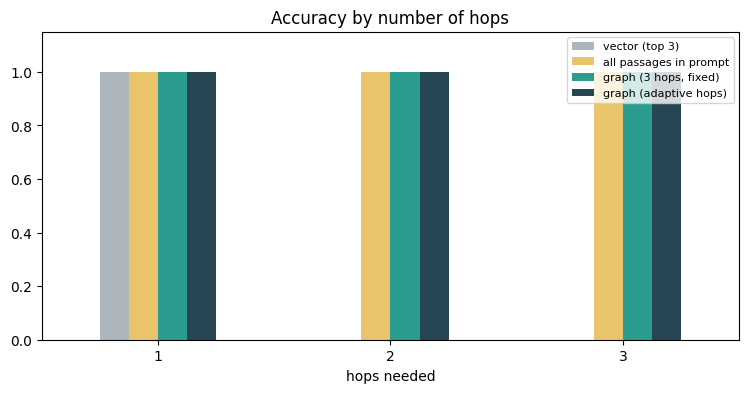


Wrong answers (read them, the check could be too strict):
        method  hops                                                                                        question        gold                    answer
vector (top 3)     2                                        Who is the CEO of the company that acquired Nimbus Labs?  Vikram Rao            not mentioned.
vector (top 3)     2                          Who is the CEO of the company that GreenGrid supplies solar panels to? Arjun Mehta                   unknown
vector (top 3)     2                      In which city is the company whose board Riya Sharma joined headquartered?      Jaipur                   unknown
vector (top 3)     3    In which city is the company that acquired the startup founded by Riya Sharma headquartered?        Pune                    jaipur
vector (top 3)     3                      Which college did the CEO of the company that acquired Nimbus Labs attend?  IIT Indore                   unknown
vector (top

In [9]:
order = ["vector (top 3)", "all passages in prompt", "graph (3 hops, fixed)", "graph (adaptive hops)"]
cost = res.groupby("method").agg(accuracy=("correct", "mean"), avg_context_words=("context_words", "mean"),
                                  avg_llm_calls=("llm_calls", "mean")).round(2).loc[order]
print(cost)

by_hops = res.pivot_table(index="hops", columns="method", values="correct", aggfunc="mean").round(2)[order]
print("\nAccuracy by hops needed:")
print(by_hops)

adaptive = res[res["method"] == "graph (adaptive hops)"]
print("\nAverage hops the adaptive method needed, by question hops:")
print(adaptive.groupby("hops")["hops_used"].mean().round(2))

by_hops.plot(kind="bar", figsize=(9, 4), color=["#adb5bd", "#e9c46a", "#2a9d8f", "#264653"])
plt.ylim(0, 1.15)
plt.title("Accuracy by number of hops")
plt.xlabel("hops needed")
plt.xticks(rotation=0)
plt.legend(fontsize=8)
plt.show()

print("\nWrong answers (read them, the check could be too strict):")
wrong = res[~res["correct"]]
print(wrong[["method", "hops", "question", "gold", "answer"]].to_string(index=False))

## Step 9: Communities and a global question
GraphRAG can also group the graph into communities and summarise each one, which helps for big-picture questions.

In [10]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G.to_undirected()))
print("Communities found:", len(communities))

summaries = []
for i, comm in enumerate(communities):
    if len(comm) < 3:
        continue
    comm_facts = []
    for a, b, data in G.edges(data=True):
        if a in comm and b in comm:
            comm_facts.append(a + " --" + data["relation"] + "--> " + b)
    text = ask_llm("Write one sentence summarising this group of related facts:\n" + "\n".join(comm_facts), system="You summarise graph communities.")
    summaries.append("Community " + str(i + 1) + " (" + ", ".join(sorted(comm)) + "): " + text.strip())
    time.sleep(0.3)

for s in summaries:
    print(s)
    print()

global_q = "What are the main groups of companies and people in this data?"
print("GLOBAL QUESTION:", global_q)
print(ask_llm("Using these community summaries, answer the question briefly.\n\n" + "\n".join(summaries) + "\n\nQuestion: " + global_q))

Communities found: 6
Community 1 (GreenGrid, Jaipur, Riya Sharma): Riya Sharma serves on the board of GreenGrid, a company headquartered in Jaipur.

Community 2 (Bhopal, Nimbus Labs, warehouse robots): Nimbus Labs, based in Bhopal, builds warehouse robots.

Community 3 (Bengaluru, Orion Systems, Pune): Orion Systems is headquartered in Pune while also maintaining a base in Bengaluru.

Community 4 (IIT Indore, Sunita Patel, Vikram Rao): Both Vikram Rao and Sunita Patel studied at IIT Indore.

Community 5 (Arjun Mehta, Chennai, Helix Motors): Helix Motors, headquartered in Chennai, is led by CEO Arjun Mehta.

Community 6 (Hyderabad, Meena Iyer, Zephyr Analytics): Zephyr Analytics, headquartered in Hyderabad, is led by CEO Meena Iyer.

GLOBAL QUESTION: What are the main groups of companies and people in this data?
**Companies**

- **GreenGrid** – headquartered in Jaipur.  
- **Nimbus Labs** – based in Bhopal, builds warehouse robots.  
- **Orion Systems** – headquartered in Pune with a ba

## Step 10: Key insights and export

In [11]:
print("KEY INSIGHTS (calculated from this run)")
print("1. Graph size:", G.number_of_nodes(), "nodes and", G.number_of_edges(), "edges. Triple extraction recall", round(recall * 100), "%, precision", round(precision * 100), "%")
print("2. Accuracy by method:", cost["accuracy"].to_dict())
print("3. Average words sent to the LLM:", cost["avg_context_words"].to_dict())

vec = cost.loc["vector (top 3)", "accuracy"]
adp = cost.loc["graph (adaptive hops)", "accuracy"]
allp = cost.loc["all passages in prompt", "accuracy"]
if adp > vec:
    print("4. Adaptive GraphRAG beat top-3 vector search by", round((adp - vec) * 100), "points on this set")
else:
    print("4. Adaptive GraphRAG did not beat top-3 vector search on this set")
if allp >= adp:
    print("5. Putting ALL passages in the prompt did as well or better, so on a corpus this small the graph is not needed. GraphRAG matters when the corpus is too big for one prompt.")
else:
    print("5. Adaptive GraphRAG beat the all-passages prompt by", round((adp - allp) * 100), "points")
print("6. Only", len(questions), "questions and", len(passages), "passages, so treat the numbers as a demo and not a benchmark")

triples_df.to_csv("graphrag_triples.csv", index=False)
res.to_csv("graphrag_vs_vector_results.csv", index=False)
print("\nSaved graphrag_triples.csv and graphrag_vs_vector_results.csv")

KEY INSIGHTS (calculated from this run)
1. Graph size: 18 nodes and 20 edges. Triple extraction recall 100 %, precision 100 %
2. Accuracy by method: {'vector (top 3)': 0.3, 'all passages in prompt': 1.0, 'graph (3 hops, fixed)': 1.0, 'graph (adaptive hops)': 1.0}
3. Average words sent to the LLM: {'vector (top 3)': 29.7, 'all passages in prompt': 143.0, 'graph (3 hops, fixed)': 79.4, 'graph (adaptive hops)': 52.3}
4. Adaptive GraphRAG beat top-3 vector search by 70 points on this set
5. Putting ALL passages in the prompt did as well or better, so on a corpus this small the graph is not needed. GraphRAG matters when the corpus is too big for one prompt.
6. Only 10 questions and 14 passages, so treat the numbers as a demo and not a benchmark

Saved graphrag_triples.csv and graphrag_vs_vector_results.csv



---
Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)